Press to Start: La evolución de los videojuegos - Python

EXPLORACION

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv(r"C:\Users\thais\Downloads\Video_Games_Sales_as_at_22_Dec_2016.csv")

df.head()

,Name,Platform,Year_of_Release,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales,Critic_Score,Critic_Count,User_Score,User_Count,Developer,Rating
0,Wii Sports,Wii,2006.0,Sports,Nintendo,41.36,28.96,3.77,8.45,82.53,76.0,51.0,8,322.0,Nintendo,E
1,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24,NaN,NaN,NaN,NaN,NaN,NaN
2,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.68,12.76,3.79,3.29,35.52,82.0,73.0,8.3,709.0,Nintendo,E
3,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.61,10.93,3.28,2.95,32.77,80.0,73.0,8,192.0,Nintendo,E
4,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16719 entries, 0 to 16718
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Name             16717 non-null  object 
 1   Platform         16719 non-null  object 
 2   Year_of_Release  16450 non-null  float64
 3   Genre            16717 non-null  object 
 4   Publisher        16665 non-null  object 
 5   NA_Sales         16719 non-null  float64
 6   EU_Sales         16719 non-null  float64
 7   JP_Sales         16719 non-null  float64
 8   Other_Sales      16719 non-null  float64
 9   Global_Sales     16719 non-null  float64
 10  Critic_Score     8137 non-null   float64
 11  Critic_Count     8137 non-null   float64
 12  User_Score       10015 non-null  object 
 13  User_Count       7590 non-null   float64
 14  Developer        10096 non-null  object 
 15  Rating           9950 non-null   object 
dtypes: float64(9), object(7)
memory usage: 2.0+ MB


In [4]:
df.describe()

,Year_of_Release,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales,Critic_Score,Critic_Count,User_Count
count,16450.000000,16719.000000,16719.000000,16719.000000,16719.000000,16719.000000,8137.000000,8137.000000,7590.000000
mean,2006.487356,0.263330,0.145025,0.077602,0.047332,0.533543,68.967679,26.360821,162.229908
std,5.878995,0.813514,0.503283,0.308818,0.186710,1.547935,13.938165,18.980495,561.282326
min,1980.000000,0.000000,0.000000,0.000000,0.000000,0.010000,13.000000,3.000000,4.000000
25%,2003.000000,0.000000,0.000000,0.000000,0.000000,0.060000,60.000000,12.000000,10.000000
50%,2007.000000,0.080000,0.020000,0.000000,0.010000,0.170000,71.000000,21.000000,24.000000
75%,2010.000000,0.240000,0.110000,0.040000,0.030000,0.470000,79.000000,36.000000,81.000000
max,2020.000000,41.360000,28.960000,10.220000,10.570000,82.530000,98.000000,113.000000,10665.000000


LIMPIEZA DE DATOS

In [5]:
# Eliminar filas con valores faltantes en las columnas 'Name', 'Genre' y 'Year_of_Release'
df_cleaned = df.dropna(subset=['Name', 'Genre', 'Year_of_Release'])

# Convertir 'Year_of_Release' a entero
df_cleaned['Year_of_Release'] = df_cleaned['Year_of_Release'].astype(int)

# Eliminar los juegos publicados en 2017 y adelante
df_cleaned = df_cleaned[df_cleaned['Year_of_Release'] < 2017]

# Eliminar los juegos de la plataforma "PC"
df_cleaned = df_cleaned[df_cleaned['Platform'] != 'PC']

# Asegurarnos de que las columnas 'Critic_Score' y 'User_Score' sean numéricas 
df_cleaned['Critic_Score'] = pd.to_numeric(df_cleaned['Critic_Score'], errors='coerce')
df_cleaned['User_Score'] = pd.to_numeric(df_cleaned['User_Score'], errors='coerce')

# Multiplicar las notas de los usuarios por 10 para adaptarlas al formato de 0-100
df_cleaned['User_Score'] = df_cleaned['User_Score'] * 10


C:\Users\thais\AppData\Local\Temp\ipykernel_30240\402941208.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cleaned['Year_of_Release'] = df_cleaned['Year_of_Release'].astype(int)


In [6]:
# Juntar las filas de el mismo videojuego que ha salido en varias plataformas en una sola fila
df_grouped_all = df_cleaned.groupby(['Name', 'Publisher']).agg({
    'NA_Sales': 'sum',
    'EU_Sales': 'sum',
    'JP_Sales': 'sum',
    'Other_Sales': 'sum',
    'Global_Sales': 'sum',
    'Critic_Score': 'mean',
    'Critic_Count': 'sum',
    'User_Score': 'mean',
    'User_Count': 'sum',
    'Platform': lambda x: ', '.join(sorted(set(x))), 
    'Year_of_Release': 'min'
}).reset_index()

In [9]:
df_grouped_all.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11263 entries, 0 to 11262
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Name             11263 non-null  object 
 1   Publisher        11263 non-null  object 
 2   NA_Sales         11263 non-null  float64
 3   EU_Sales         11263 non-null  float64
 4   JP_Sales         11263 non-null  float64
 5   Other_Sales      11263 non-null  float64
 6   Global_Sales     11263 non-null  float64
 7   Critic_Score     4842 non-null   float64
 8   Critic_Count     11263 non-null  float64
 9   User_Score       4375 non-null   float64
 10  User_Count       11263 non-null  float64
 11  Platform         11263 non-null  object 
 12  Year_of_Release  11263 non-null  int64  
dtypes: float64(9), int64(1), object(3)
memory usage: 1.1+ MB


ANALISIS EXPLORATORIO

<Figure size 1600x800 with 0 Axes>

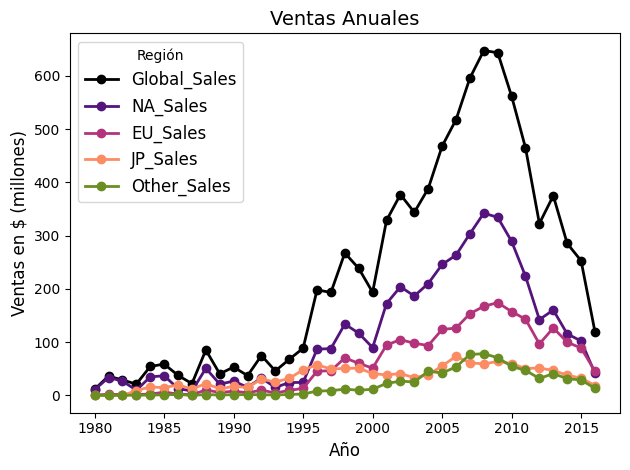

In [24]:
# Evolución de las ventas globales a lo largo del tiempo

custom_palette = ['#000000', '#54147c', '#b4347c', '#fc8c64', '#6B8E23']  

# Seleccionar las columnas de ventas
sales_columns = ['Global_Sales', 'NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales']

# Agrupar por año y sumar las ventas
sales_by_year = df_grouped_all.groupby('Year_of_Release')[sales_columns].sum()

plt.figure(figsize=(16, 8))
sales_by_year.plot(kind='line', marker='o', color=custom_palette, linewidth=2)
plt.xlabel("Año", fontsize=12)
plt.ylabel("Ventas en $ (millones)", fontsize=12)
plt.title("Ventas Anuales", fontsize=14)
plt.legend(title="Región", fontsize=12)
plt.tight_layout()
plt.show()

In [ ]:
# Definir los periodos de años
periodos = {
    '1980-1994': (1980, 1994),
    '1995-2000': (1995, 2000),
    '2001-2007': (2001, 2007),
    '2008-2016': (2008, 2016)
}

# Crear diccionario
resultados_periodos = {}

# Calcular los juegos más vendidos por cada periodo
for periodo, (start_year, end_year) in periodos.items():
    # Filtrar los juegos por el periodo de tiempo
    df_periodo = df_cleaned[(df_cleaned['Year_of_Release'] >= start_year) & (df_cleaned['Year_of_Release'] <= end_year)]
    
    # Verificar si el periodo contiene datos
    if df_periodo.empty:
        print(f"No hay datos disponibles para el periodo {periodo}.")
        continue

    # Sumar las ventas globales por juego
    ventas_por_juego = df_periodo.groupby('Name')['Global_Sales'].sum().nlargest(10)  # Top 10 juegos más vendidos
    
    # Sumar las ventas globales por plataforma
    ventas_por_plataforma = df_periodo.groupby('Platform')['Global_Sales'].sum().nlargest(5)  # Top 5 plataformas más vendidas
    
    # Guardar los resultados en el diccionario
    resultados_periodos[periodo] = {
        'top_juegos': ventas_por_juego,
        'top_plataformas': ventas_por_plataforma
    }

for periodo, datos in resultados_periodos.items():
    print(f"\n{periodo}:\n")
    print("Top 10 juegos más vendidos:")
    print(datos['top_juegos'])
    print("\nTop 5 plataformas más vendidas:")
    print(datos['top_plataformas'])



1980-1994:

Top 10 juegos más vendidos:
Name
Super Mario Bros.                     40.24
Tetris                                35.84
Duck Hunt                             28.31
Super Mario World                     20.61
Super Mario Land                      18.14
Super Mario Bros. 3                   17.28
Super Mario Land 2: 6 Golden Coins    11.18
Super Mario All-Stars                 10.55
Dr. Mario                             10.19
Donkey Kong Country                    9.30
Name: Global_Sales, dtype: float64

Top 5 plataformas más vendidas:
Platform
NES     251.07
SNES    150.44
GB      114.52
2600     86.57
GEN      28.36
Name: Global_Sales, dtype: float64

1995-2000:

Top 10 juegos más vendidos:
Name
Pokemon Red/Pokemon Blue                   31.37
Pokemon Gold/Pokemon Silver                23.10
Pokémon Yellow: Special Pikachu Edition    14.64
Super Mario 64                             11.89
Gran Turismo                               10.95
Mario Kart 64                       

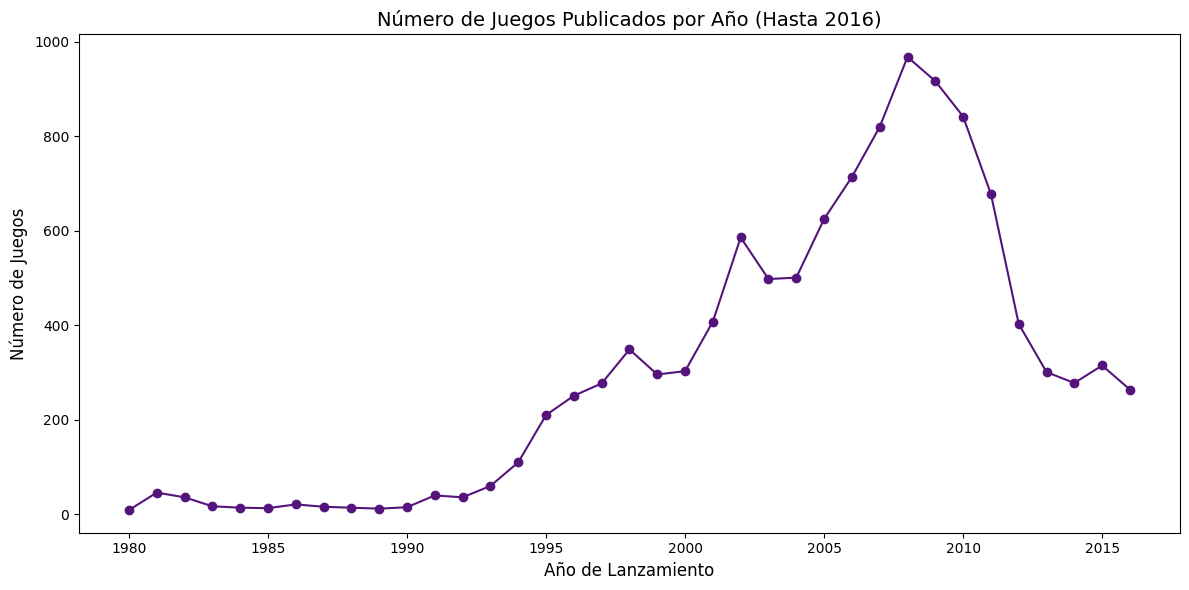

In [19]:
# Número de juegos publicados por año:
# Ver cuántos juegos se han lanzado cada año y observar si ha habido un aumento o disminución significativa en la cantidad de juegos.

df_games_per_year = df_grouped_all.groupby('Year_of_Release')['Name'].count()

plt.figure(figsize=(12, 6))
df_games_per_year.plot(kind='line', marker='o', color=custom_palette[1])
plt.title('Número de Juegos Publicados por Año (Hasta 2016)', fontsize=14)
plt.xlabel('Año de Lanzamiento', fontsize=12)
plt.ylabel('Número de Juegos', fontsize=12)
plt.tight_layout()
plt.show()


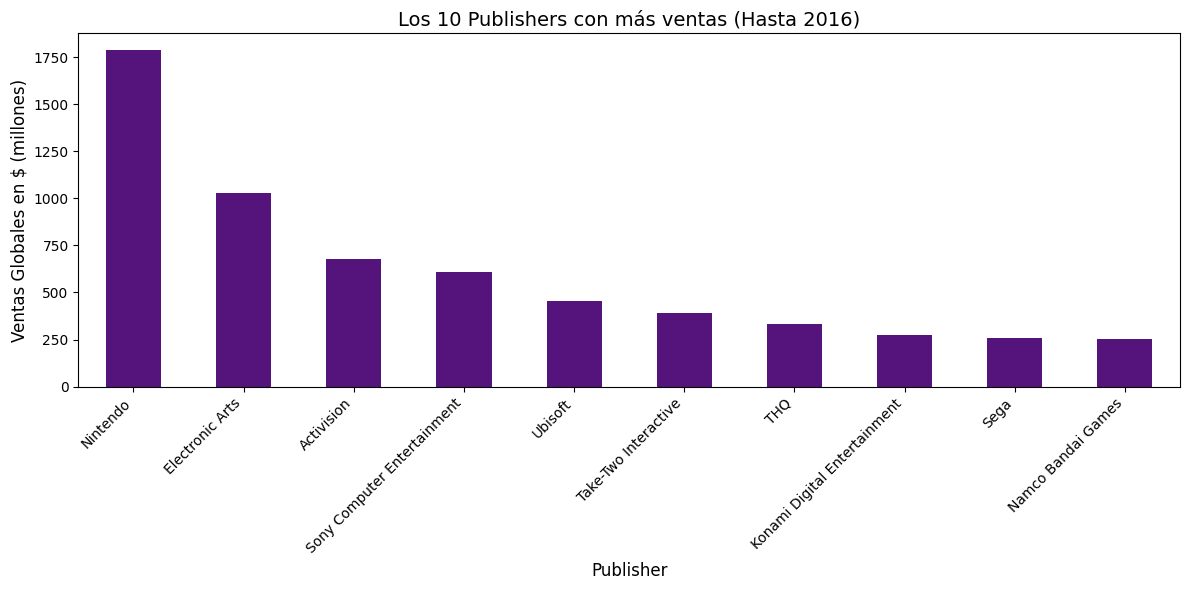

In [ ]:
# Top publishers:
# Identificar los publishers con más ventas

df_publishers = df_grouped_all.groupby('Publisher').agg({
    'Name': 'count',
    'Global_Sales': 'sum'
}).reset_index()

df_publishers_sorted_by_sales = df_publishers.sort_values(by='Global_Sales', ascending=False)
df_publishers_top_10 = df_publishers_sorted_by_sales.head(10)

plt.figure(figsize=(12, 6))
df_publishers_top_10.set_index('Publisher')['Global_Sales'].plot(kind='bar', color=custom_palette[1])  
plt.title('Los 10 Publishers con más ventas (Hasta 2016)', fontsize=14)
plt.xlabel('Publisher', fontsize=12)
plt.ylabel('Ventas Globales en $ (millones)', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.tight_layout()
plt.show()


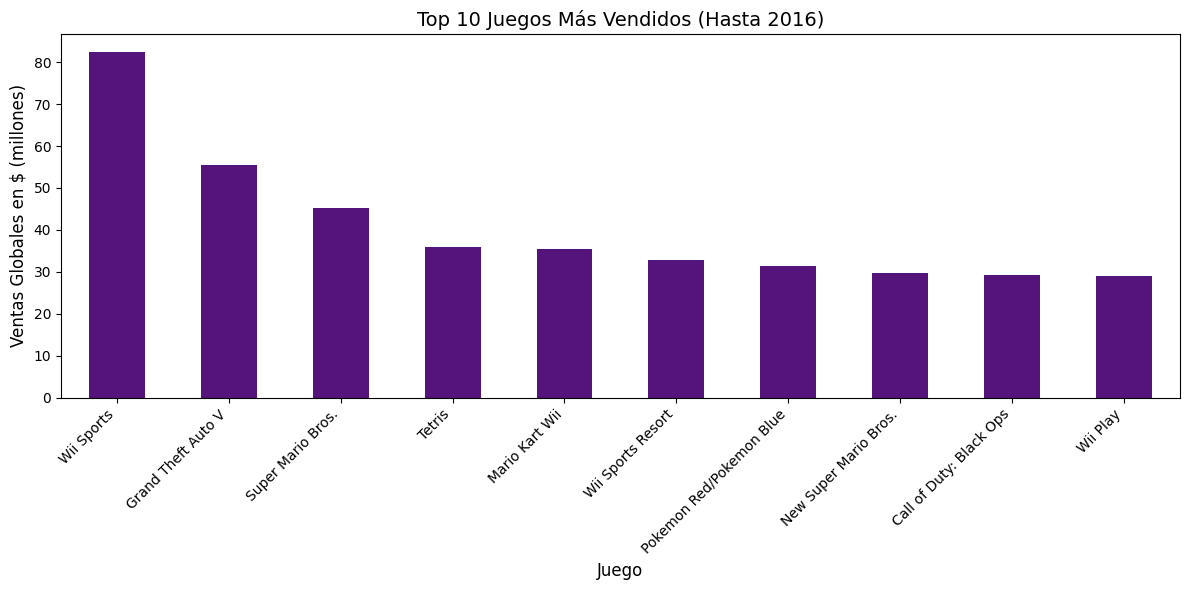

In [27]:
# Juegos más vendidos
top_10_games_global_sales = df_grouped_all.sort_values(by='Global_Sales', ascending=False).head(10)

plt.figure(figsize=(12, 6))
top_10_games_global_sales.set_index('Name')['Global_Sales'].plot(kind='bar', color=custom_palette[1])  
plt.title('Top 10 Juegos Más Vendidos (Hasta 2016)', fontsize=14)
plt.xlabel('Juego', fontsize=12)
plt.ylabel('Ventas Globales en $ (millones)', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.tight_layout()
plt.show()

HIPOTESIS / PREGUNTAS

<Figure size 1000x600 with 0 Axes>

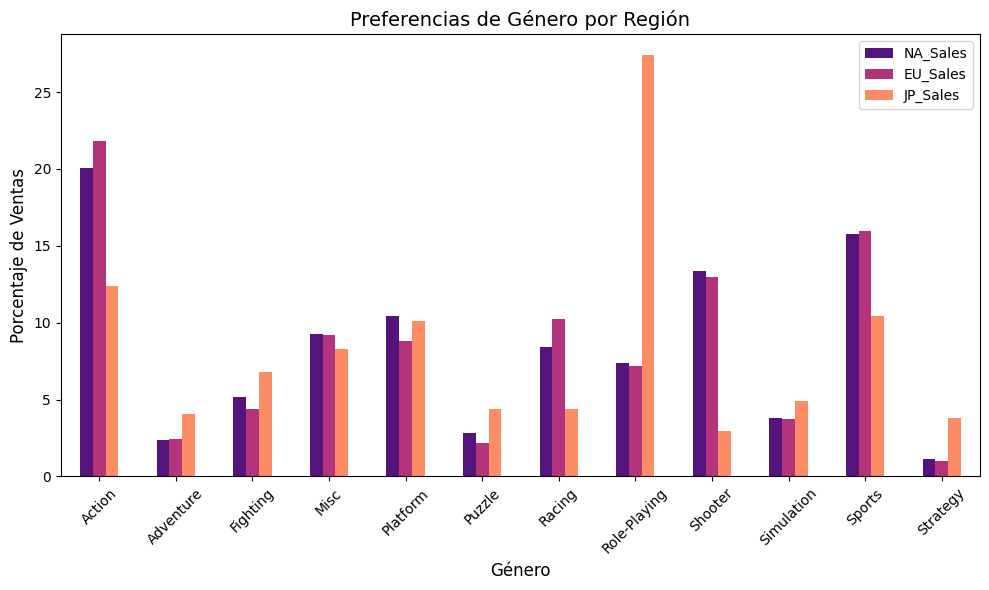

In [ ]:
# ¿Gustan los mismos tipos de juegos en NA, EU y JP?

# Calcular las ventas totales por región
region_sales = df_cleaned[['Genre', 'NA_Sales', 'EU_Sales', 'JP_Sales']].groupby('Genre').sum()

# Calcular los porcentajes de ventas por género en cada región
region_sales_percentage = region_sales.div(region_sales.sum(axis=0), axis=1) * 100

custom_palette2 = ['#54147c', '#b4347c', '#fc8c64'] 

plt.figure(figsize=(10, 6))
region_sales_percentage.plot(kind='bar', figsize=(10, 6), color=custom_palette2)
plt.title('Preferencias de Género por Región', fontsize=14)
plt.xlabel('Género', fontsize=12)
plt.ylabel('Porcentaje de Ventas', fontsize=12)
plt.xticks(rotation=45, fontsize=10)
plt.tight_layout()
plt.show()

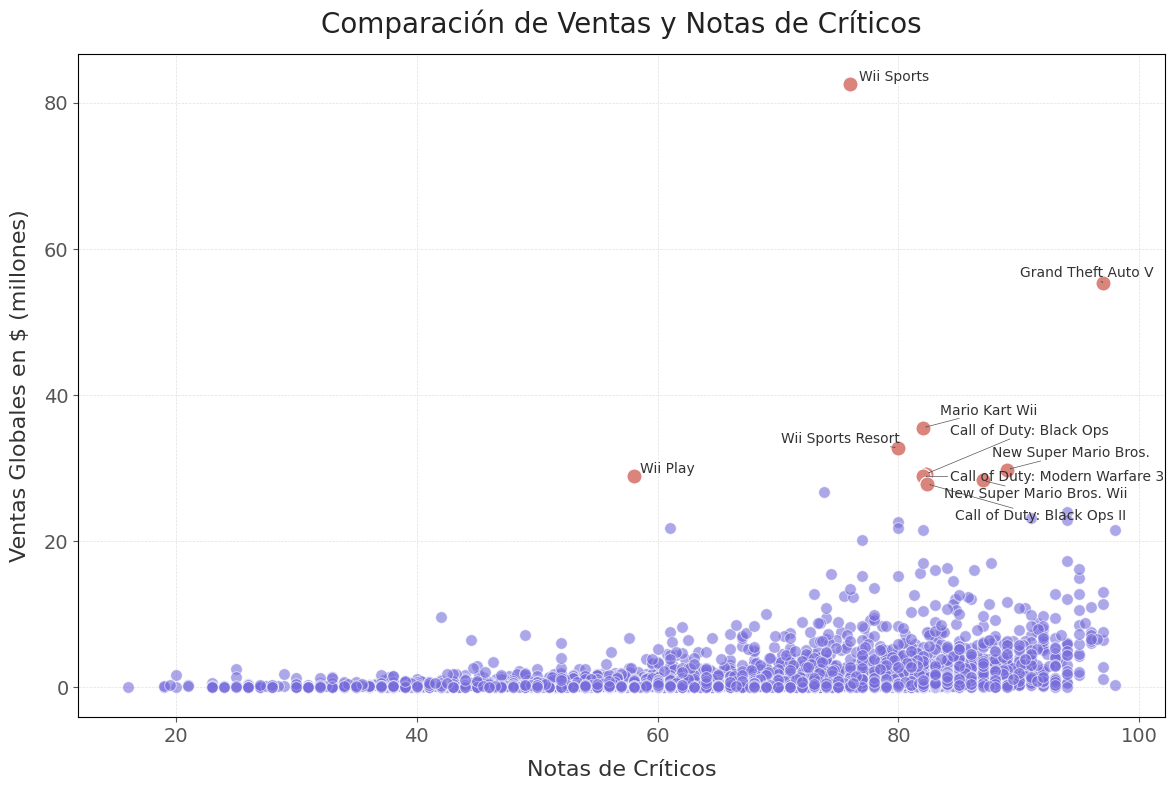

In [ ]:
# ¿Influyen las notas de los críticos en las ventas globales? 

import numpy as np
from adjustText import adjust_text

# Crear un df para juegos con notas
df_critics_full = df_grouped_all.dropna(subset=['Critic_Score'])

# Identificar los 10 juegos con mayores ventas 
top_outliers = df_critics_full.nlargest(10, 'Global_Sales')

fig, ax = plt.subplots(figsize=(12, 8))
sns.scatterplot(data=df_critics_full, x='Critic_Score', y='Global_Sales', alpha=0.6, s=70, color='#766CDB', ax=ax)
sns.scatterplot(data=top_outliers, x='Critic_Score', y='Global_Sales', s=120, color='#DA847C', ax=ax) # Resaltar los outliers con un color diferente

# Ajustar automáticamente la posición de los textos para evitar superposiciones
texts = []
for i, row in top_outliers.iterrows():
    texts.append(ax.text(row['Critic_Score'], row['Global_Sales'], row['Name'], fontsize=10, color='#333333'))
adjust_text(texts, arrowprops=dict(arrowstyle='->', color='#555555', lw=0.5))

ax.set_title('Comparación de Ventas y Notas de Críticos', pad=15, fontsize=20, color='#222222')
ax.set_xlabel('Notas de Críticos', labelpad=10, fontsize=16, color='#333333')
ax.set_ylabel('Ventas Globales en $ (millones)', labelpad=10, fontsize=16, color='#333333')
ax.tick_params(axis='both', labelsize=14, colors='#555555')
ax.grid(True, linestyle='--', linewidth=0.5, color='#E0E0E0')
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()